In [1]:
!pip install pandas

In [45]:

 # task 0 part 1
import pandas as pd

# 1. Load the raw dictionary
raw_dict = pd.read_pickle("delta_a100_gpu_xid_dataset.pkl")

# 3. Flatten the dictionary into a single list of all errors
all_errors = []
for date, error_list in raw_dict.items():
   all_errors.extend(error_list)

# 4. Convert that list into a Pandas DataFrame
df = pd.DataFrame(all_errors)
df.sort_values(by = 'timestamp')

df.head(6)


,timestamp,datetime,XID,Tag,node_name,device_id
0,1.658072e+09,2022-07-17T10:27:27.422837-05:00,119,119_GSP_RPC_timeout,gpua088,0000:c7:00
1,1.658072e+09,2022-07-17T10:29:29.304632-05:00,45,045_GPU_PREEMPTIVE_CLEANUP,gpua048,0000:07:00
2,1.658074e+09,2022-07-17T11:03:11.093546-05:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION,gpua001,0000:85:00
3,1.658074e+09,2022-07-17T11:04:15.807907-05:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION,gpua044,0000:85:00
4,1.658074e+09,2022-07-17T11:10:53.818266-05:00,43,043_GPU_STOPPED_PROCESSING,gpua045,0000:07:00
5,1.658075e+09,2022-07-17T11:16:30.534940-05:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION,gpua001,0000:c7:00


In [51]:

march_10_2024_errors = df[df['datetime'].astype(str).str.startswith('2024-03-10')]

march_10_2024_errors.head(9) # see the first few rows in pandas



,timestamp,datetime,XID,Tag,node_name,device_id
49368,1.710047e+09,2024-03-10T00:07:03.882015-05:00,43,043_GPU_STOPPED_PROCESSING,gpua014,0000:07:00
49369,1.710047e+09,2024-03-10T00:08:19.391145-05:00,43,043_GPU_STOPPED_PROCESSING,gpua072,0000:85:00
49370,1.710047e+09,2024-03-10T00:11:39.689608-05:00,43,043_GPU_STOPPED_PROCESSING,gpua010,0000:46:00
49371,1.710049e+09,2024-03-10T00:28:36.850641-05:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION,gpua001,0000:46:00
49372,1.710049e+09,2024-03-10T00:41:02.058856-05:00,119,119_GSP_RPC_timeout,gpua083,0000:46:00
49373,1.710050e+09,2024-03-10T00:49:47.742834-05:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION,gpua001,0000:c7:00
49374,1.710050e+09,2024-03-10T00:55:44.740825-05:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION,gpua017,0000:85:00
49375,1.710051e+09,2024-03-10T01:04:59.972015-05:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION,gpua001,0000:c7:00
49376,1.710052e+09,2024-03-10T01:26:45.244245-05:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION,gpua001,0000:07:00


In [40]:
#task 0 part 2 and 3 
count_XID = set(march_10_2024_errors['XID']) # existance hash set to see unique XID's
print('the number of unique XIDs:', len(count_XID)) # its 6 
print('here is all the unique ones')
for i in count_XID:
    print(i)

# convert back to list for task 0 pt 2.2
Uniq_XID = list(count_XID)
print(Uniq_XID) 

the number of unique XIDs: 6
here is all the unique ones
74
43
45
13
119
31
[74, 43, 45, 13, 119, 31]


In [41]:
!pip install matplotlib

In [43]:
# Task 1 part 1 print the first 10 rows (already in increasing order by timestamp)

df.head(11) 


,timestamp,datetime,XID,Tag,node_name,device_id
0,1.658072e+09,2022-07-17T10:27:27.422837-05:00,119,119_GSP_RPC_timeout,gpua088,0000:c7:00
1,1.658072e+09,2022-07-17T10:29:29.304632-05:00,45,045_GPU_PREEMPTIVE_CLEANUP,gpua048,0000:07:00
2,1.658074e+09,2022-07-17T11:03:11.093546-05:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION,gpua001,0000:85:00
3,1.658074e+09,2022-07-17T11:04:15.807907-05:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION,gpua044,0000:85:00
4,1.658074e+09,2022-07-17T11:10:53.818266-05:00,43,043_GPU_STOPPED_PROCESSING,gpua045,0000:07:00
5,1.658075e+09,2022-07-17T11:16:30.534940-05:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION,gpua001,0000:c7:00
6,1.658075e+09,2022-07-17T11:27:40.849346-05:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION,gpua001,0000:c7:00
7,1.658078e+09,2022-07-17T12:10:20.898006-05:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION,gpua072,0000:85:00
8,1.658082e+09,2022-07-17T13:21:30.008143-05:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION,gpua081,0000:85:00
9,1.658082e+09,2022-07-17T13:21:34.279469-05:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION,gpua005,0000:c7:00


In [59]:
# Prob XID 43 = Number of times XID is 43 / Total Amount of Rows of Data
# task 1 part 2 a
count_XID_43 = df[df['XID'] == 43] 
#number of errors with XID = 43

print('errors with XID equals 43:' , len(count_XID_43))

#total rows
total = len(df)
print('all rows total:' , total)

Probability_Task1_Part2a = len(count_XID_43)/total
print('probability that XID = 43 when random sample:', Probability_Task1_Part2)

errors with XID equals 43: 8592
all rows total: 73514
probability that XID = 43 when random sample: 0.11687569714612182


In [61]:
#task 1 part 2 b
count_XID_119 = df[df['XID'] == 119] 
#number of errors with XID = 119

print('errors with XID equals 119:' , len(count_XID_119))

#total rows
print('all rows total:' , total)

Probability_Task1_Part2b = len(count_XID_119)/total
print('probability that XID = 43 when random sample:', Probability_Task1_Part2b)

errors with XID equals 43: 1303
all rows total: 73514
probability that XID = 43 when random sample: 0.017724515058356233


In [ ]:
# task 1 part 2 c
# user error is way more likely than hardware error 0.116>0.0177

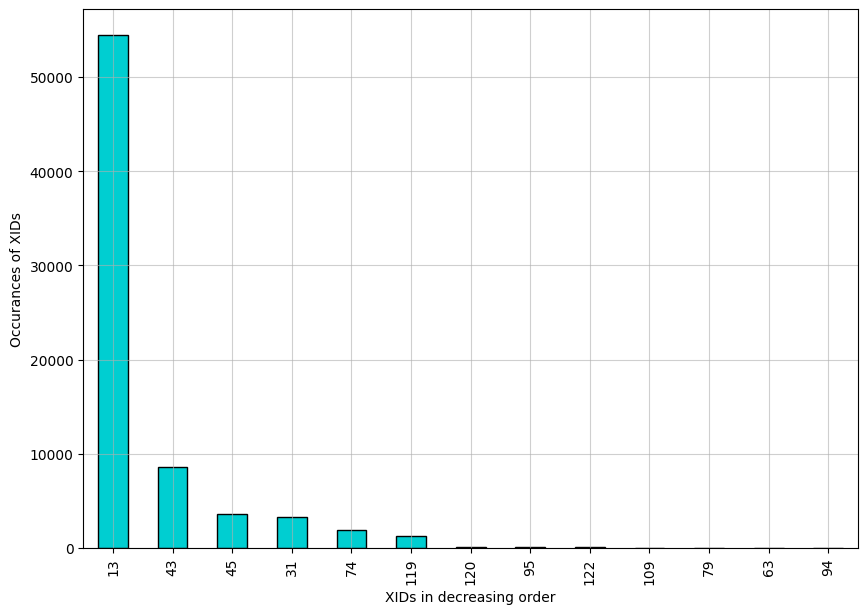

In [84]:
import matplotlib.pyplot as plt
plot_errorXIDs = df['XID'].value_counts()
plt.figure(figsize=(10,7))
# yoo dark turquoise is the color for sure
plot_errorXIDs.sort_values(ascending = False).plot(kind = 'bar', color = 'darkturquoise' , edgecolor = 'black' ) 

plt.xlabel('XIDs in decreasing order')
plt.ylabel('Occurances of XIDs')

plt.grid(axis = 'x', linestyle = '-', alpha = 0.6)
plt.grid(axis = 'y', linestyle = '-', alpha = 0.6)
plt.show()
